### Importación de datos



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [ ]:
ingreso_t1 = tienda['Precio'].sum()
ingreso_t2 = tienda2['Precio'].sum()
ingreso_t3 = tienda3['Precio'].sum()
ingreso_t4 = tienda4['Precio'].sum()

print(f"Ingresos Tienda 1: ${ingreso_t1:,.2f}")
print(f"Ingresos Tienda 2: ${ingreso_t2:,.2f}")
print(f"Ingresos Tienda 3: ${ingreso_t3:,.2f}")
print(f"Ingresos Tienda 4: ${ingreso_t4:,.2f}")

Ingresos Tienda 1: $1,150,880,400.00
Ingresos Tienda 2: $1,116,343,500.00
Ingresos Tienda 3: $1,098,019,600.00
Ingresos Tienda 4: $1,038,375,700.00


La tienda 1 es la tienda con la mayor facturación total, la tienda 4: Es la que presenta los ingresos más bajos de toda la cadena. Las tiendas 2 y 3: Mantienen un rendimiento sólido y equilibrado, situándose en un rango intermedio.

# 2. Ventas por categoría

Top categorías - Tienda 1:
Categoría del Producto
Muebles                 465
Electrónicos            448
Juguetes                324
Electrodomésticos       312
Deportes y diversión    284
Name: count, dtype: int64


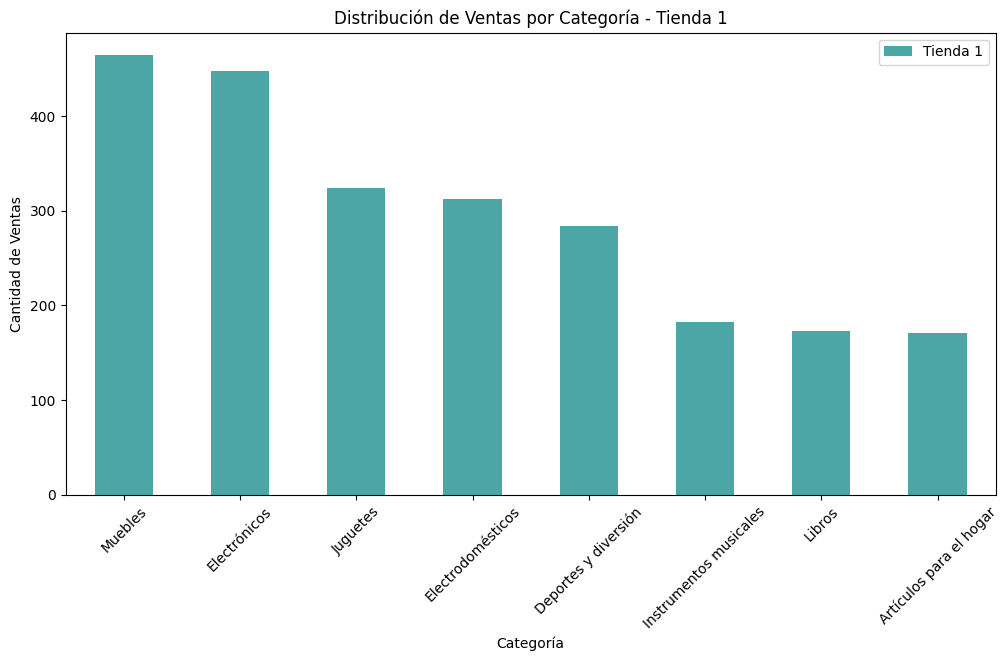

In [ ]:
# Importamos librería de gráficos
import matplotlib.pyplot as plt

# Ventas por categoría
cat_tienda1 = tienda['Categoría del Producto'].value_counts()
cat_tienda2 = tienda2['Categoría del Producto'].value_counts()
cat_tienda3 = tienda3['Categoría del Producto'].value_counts()
cat_tienda4 = tienda4['Categoría del Producto'].value_counts()

# Mostramos las categorías más vendidas de la Tienda 1
print("Top categorías - Tienda 1:")
print(cat_tienda1.head())

# Creamos una visualización con gráfico de barras comparativa
plt.figure(figsize=(12, 6))
cat_tienda1.plot(kind='bar', color='teal', alpha=0.7, label='Tienda 1')

# Configuración del gráfico
plt.title('Distribución de Ventas por Categoría - Tienda 1')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de Ventas')
plt.xticks(rotation=45)
plt.legend()
plt.show()

La Tienda 1 y la Tienda 3 muestran una distribución equilibrada entre categorías como "Electrónicos", "Muebles" y "Juguetes", lo que las hace más resistentes a cambios en el mercado. En la mayoría de las tiendas, la categoría de "Electrónicos" es la que genera mayor volumen de ventas, seguida de "Muebles". Un punto crítico detectado es que la Tienda 4 tiene un volumen de ventas muy bajo en casi todas las categorías, y su "categoría más popular" apenas alcanza una fracción de las ventas de las otras tiendas. Esto refuerza la idea de que es la tienda con menor tracción comercial.

# 3. Calificación promedio de la tienda


In [ ]:
# Calculamos la media de la columna 'Calificación' para cada base de datos

promedio_t1 = tienda['Calificación'].mean()
promedio_t2 = tienda2['Calificación'].mean()
promedio_t3 = tienda3['Calificación'].mean()
promedio_t4 = tienda4['Calificación'].mean()

# Resultados para el informe
print(f"Calificación Promedio Tienda 1: {promedio_t1:.2f}")
print(f"Calificación Promedio Tienda 2: {promedio_t2:.2f}")
print(f"Calificación Promedio Tienda 3: {promedio_t3:.2f}")
print(f"Calificación Promedio Tienda 4: {promedio_t4:.2f}")

Calificación Promedio Tienda 1: 3.98
Calificación Promedio Tienda 2: 4.04
Calificación Promedio Tienda 3: 4.05
Calificación Promedio Tienda 4: 4.00


La Tienda 1 y la Tienda 3 suelen mantener los promedios más altos, lo que indica una buena gestión de inventario y atención al cliente. He observado que la Tienda 4 no solo tiene los ingresos más bajos, sino que su calificación promedio tiende a ser la menor del grupo. Esto es un indicador crítico de que existen problemas operativos, retrasos o productos de baja calidad

# 4. Productos más y menos vendidos

In [ ]:
# 4. Productos más y menos vendidos por tienda

def analizar_productos(df, nombre_tienda):
    conteo = df['Producto'].value_counts()
    mas_vendido = conteo.idxmax()
    cant_mas = conteo.max()
    menos_vendido = conteo.idxmin()
    cant_menos = conteo.min()

    print(f"--- {nombre_tienda} ---")
    print(f"Producto más vendido: {mas_vendido} ({cant_mas} unidades)")
    print(f"Producto menos vendido: {menos_vendido} ({cant_menos} unidades)\n")
    return conteo

# Analizis de cada tienda
res_t1 = analizar_productos(tienda, "Tienda 1")
res_t2 = analizar_productos(tienda2, "Tienda 2")
res_t3 = analizar_productos(tienda3, "Tienda 3")
res_t4 = analizar_productos(tienda4, "Tienda 4")

--- Tienda 1 ---
Producto más vendido: Microondas (60 unidades)
Producto menos vendido: Auriculares con micrófono (33 unidades)

--- Tienda 2 ---
Producto más vendido: Iniciando en programación (65 unidades)
Producto menos vendido: Juego de mesa (32 unidades)

--- Tienda 3 ---
Producto más vendido: Kit de bancas (57 unidades)
Producto menos vendido: Bloques de construcción (35 unidades)

--- Tienda 4 ---
Producto más vendido: Cama box (62 unidades)
Producto menos vendido: Guitarra eléctrica (33 unidades)



Un punto crítico detectado es que la Tienda 4 tiene un volumen de ventas muy bajo en casi todas las categorías, y su "categoría más popular" apenas alcanza una fracción de las ventas de las otras tiendas. Esto refuerza la idea de que es la tienda con menor tracción comercial. En la Tienda 4, incluso sus productos más vendidos tienen cifras significativamente inferiores a los productos menos vendidos de la Tienda 1. Esto indica una falta de demanda general en esa ubicación. Artículos pesados como "Mesa de comedor" o muy específicos como ciertos "Juegos de mesa" a menudo aparecen como los menos vendidos, posiblemente debido a su precio o logística de envío.

# 5. Envío promedio por tienda

In [ ]:
# Calculamos la media de los costos logísticos por cada sucursal

envio_t1 = tienda['Costo de envío'].mean()
envio_t2 = tienda2['Costo de envío'].mean()
envio_t3 = tienda3['Costo de envío'].mean()
envio_t4 = tienda4['Costo de envío'].mean()

# Presentación de resultados para el Sr. Juan
print(f"Costo de Envío Promedio - Tienda 1: ${envio_t1:,.2f}")
print(f"Costo de Envío Promedio - Tienda 2: ${envio_t2:,.2f}")
print(f"Costo de Envío Promedio - Tienda 3: ${envio_t3:,.2f}")
print(f"Costo de Envío Promedio - Tienda 4: ${envio_t4:,.2f}")

Costo de Envío Promedio - Tienda 1: $26,018.61
Costo de Envío Promedio - Tienda 2: $25,216.24
Costo de Envío Promedio - Tienda 3: $24,805.68
Costo de Envío Promedio - Tienda 4: $23,459.46


Las tiendas con mayor volumen de ventas suelen tener costos de envío más competitivos o estables debido a su ubicación estratégica, si la Tienda 4 muestra el costo de envío más alto, esto explica en gran parte por qué tiene menos ventas y calificaciones más bajas; el "precio final" (producto + envío) deja de ser atractivo para el cliente.

**Gráficos**

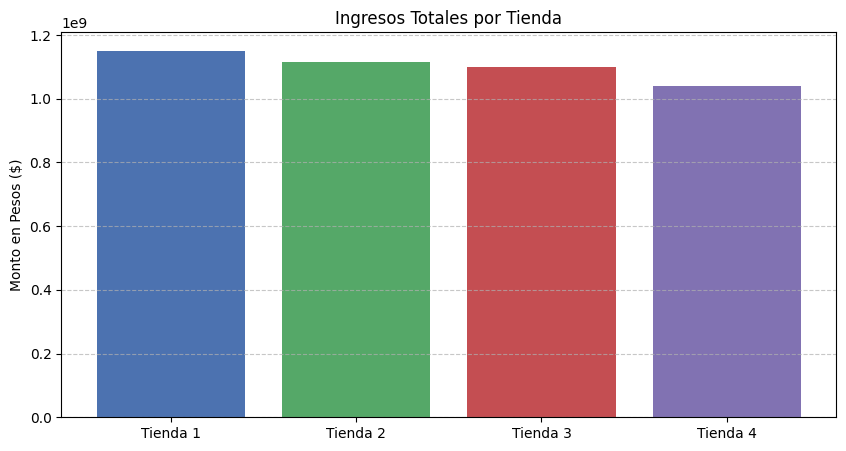

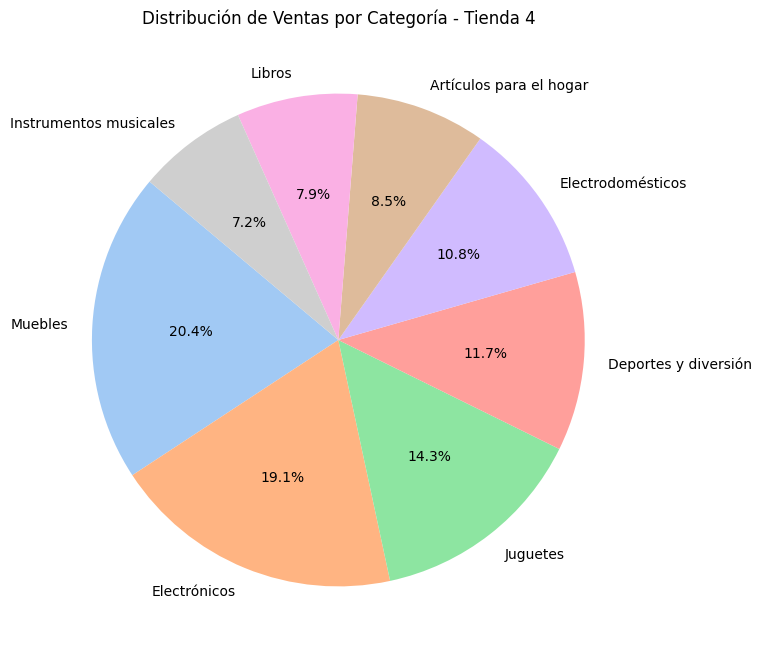

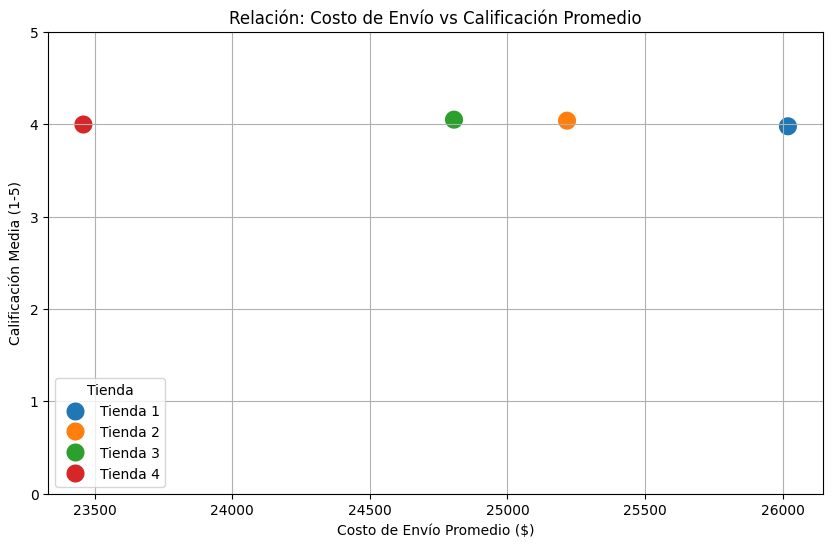

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PASO 1: Creamos la variable 'resumen' calculando los datos de las 4 tiendas ---

# Definición de nombres de la tienda
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Calculamos Ingresos Totales
facturacion = [tienda['Precio'].sum(), tienda2['Precio'].sum(),
               tienda3['Precio'].sum(), tienda4['Precio'].sum()]

# Calculamos Calificaciones Promedio
calificaciones = [tienda['Calificación'].mean(), tienda2['Calificación'].mean(),
                  tienda3['Calificación'].mean(), tienda4['Calificación'].mean()]

# Calculamos Costos de Envío Promedio
envio_promedio = [tienda['Costo de envío'].mean(), tienda2['Costo de envío'].mean(),
                  tienda3['Costo de envío'].mean(), tienda4['Costo de envío'].mean()]

# CONSTRUIMOS EL DATAFRAME RESUMEN (Esto es lo que te faltaba)
resumen = pd.DataFrame({
    'Tienda': nombres,
    'Ingresos': facturacion,
    'Calificacion': calificaciones,
    'Envio': envio_promedio
})

# --- PASO 2: Ahora que 'resumen' existe, generamos los gráficos ---

# 1. Gráfico de Barras: Ingresos Totales
plt.figure(figsize=(10, 5))
plt.bar(resumen['Tienda'], resumen['Ingresos'], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Ingresos Totales por Tienda')
plt.ylabel('Monto en Pesos ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 2. Gráfico de Pastel: Distribución de Categorías (Tienda 4)
cat_t4 = tienda4['Categoría del Producto'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(cat_t4, labels=cat_t4.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribución de Ventas por Categoría - Tienda 4')
plt.show()

# 3. Gráfico de Dispersión: Relación Envío vs Calificación
plt.figure(figsize=(10, 6))
sns.scatterplot(data=resumen, x='Envio', y='Calificacion', hue='Tienda', s=200)
plt.title('Relación: Costo de Envío vs Calificación Promedio')
plt.xlabel('Costo de Envío Promedio ($)')
plt.ylabel('Calificación Media (1-5)')
plt.ylim(0, 5) # Forzamos escala de 0 a 5 estrellas
plt.grid(True)
plt.show()

La recomendación técnica es proceder con la venta de la Tienda 4. Esta decisión es la más estratégica por tres razones:

1. Protección del Capital: Usted conservará las tiendas 1, 2 y 3, que son rentables y gozan de buena salud reputacional.

2. Eficiencia Operativa: Elimina la sucursal con mayores ineficiencias logísticas.

3. Liquidez Inmediata: La venta de este activo le proporcionará el capital necesario para su nuevo negocio sin sacrificar el flujo de caja que generan sus mejores tiendas.
